# Chronic Kidney Disease - Model Training

This dataset needs more preprocessing than the other two (mixed numeric/categorical columns, real missing values, text cleanup). Steps:
1. Full cleaning pipeline (reusing logic from the EDA notebook)
2. Encode categorical columns, impute missing values
3. Classical ML: Logistic Regression, Random Forest, XGBoost
4. Deep Learning: ANN with activation function comparison
5. Final comparison + save best model

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

from preprocessing import load_data, handle_missing_values, encode_categorical, scale_features

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
df = load_data('../data/kidney_disease.csv')
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

df = df.replace('?', np.nan)
df = df.replace('nan', np.nan)

for col in ['pcv', 'wc', 'rc']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'id' in df.columns:
    df = df.drop(columns=['id'])

print(df.shape)
df.head()

(400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [3]:
target_col = 'classification' if 'classification' in df.columns else df.columns[-1]
df[target_col] = df[target_col].astype(str).str.strip()
# Standardize target labels - dataset sometimes has 'ckd\t' or similar artifacts
df[target_col] = df[target_col].replace({'ckd\t': 'ckd'})
y = df[target_col].map({'ckd': 1, 'notckd': 0})

df_features = df.drop(columns=[target_col])

In [4]:
# Impute missing values (median for numeric, most frequent for categorical)
df_features = handle_missing_values(df_features)

# Encode categorical (yes/no, normal/abnormal, etc.) columns
cat_cols = df_features.select_dtypes(exclude=[np.number]).columns.tolist()
print('Categorical columns to encode:', cat_cols)

X = encode_categorical(df_features, cat_cols)
print(X.shape)
X.head()

Categorical columns to encode: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
(400, 24)


,age,bp,sg,al,su,bgr,bu,sc,sod,pot,...,rbc_normal,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_poor,pe_yes,ane_yes
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,138.0,4.4,...,True,True,False,False,True,True,False,False,False,False
1,7.0,50.0,1.020,4.0,0.0,121.0,18.0,0.8,138.0,4.4,...,True,True,False,False,False,False,False,False,False,False
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,138.0,4.4,...,True,True,False,False,False,True,False,True,False,True
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,...,True,False,True,False,True,False,False,True,True,True
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,138.0,4.4,...,True,True,False,False,False,False,False,False,False,False


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test, save_path='../models/kidney_scaler.pkl')
print('Train shape:', X_train_scaled.shape, ' Test shape:', X_test_scaled.shape)

Train shape: (320, 24)  Test shape: (80, 24)


## Part 1: Classical ML Models

In [6]:
results = {}

def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else preds
    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba)
    }
    print(f'--- {name} ---')
    for k, v in results[name].items():
        print(f'{k}: {v:.4f}')
    print()

In [7]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
evaluate_model('Logistic Regression', log_reg, X_test_scaled, y_test)

--- Logistic Regression ---
Accuracy: 0.9875
Precision: 1.0000
Recall: 0.9800
F1: 0.9899
ROC-AUC: 1.0000



In [8]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train_scaled, y_train)
evaluate_model('Random Forest', rf, X_test_scaled, y_test)

--- Random Forest ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1: 1.0000
ROC-AUC: 1.0000



In [9]:
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_scaled, y_train)
evaluate_model('XGBoost', xgb, X_test_scaled, y_test)

--- XGBoost ---
Accuracy: 0.9875
Precision: 1.0000
Recall: 0.9800
F1: 0.9899
ROC-AUC: 1.0000



C:\Users\harsh\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [14:08:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Part 2: Deep Learning - ANN

In [10]:
def build_ann(input_dim, hidden_activation='relu', output_activation='sigmoid'):
    model = Sequential([
        Dense(32, activation=hidden_activation, input_shape=(input_dim,)),
        Dense(16, activation=hidden_activation),
        Dense(8, activation=hidden_activation),
        Dense(1, activation=output_activation)
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [11]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

ann_relu = build_ann(X_train_scaled.shape[1], hidden_activation='relu')
history_relu = ann_relu.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

loss, acc = ann_relu.evaluate(X_test_scaled, y_test, verbose=0)
print(f'ANN (ReLU) Test Accuracy: {acc:.4f}')

C:\Users\harsh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ANN (ReLU) Test Accuracy: 0.9875


In [12]:
preds_proba = ann_relu.predict(X_test_scaled).flatten()
preds = (preds_proba > 0.5).astype(int)

results['ANN (ReLU)'] = {
    'Accuracy': accuracy_score(y_test, preds),
    'Precision': precision_score(y_test, preds),
    'Recall': recall_score(y_test, preds),
    'F1': f1_score(y_test, preds),
    'ROC-AUC': roc_auc_score(y_test, preds_proba)
}
print(results['ANN (ReLU)'])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
{'Accuracy': 0.9875, 'Precision': 1.0, 'Recall': 0.98, 'F1': 0.98989898989899, 'ROC-AUC': 1.0}


## Part 3: Activation Function Comparison

In [13]:
activation_functions = ['relu', 'tanh', 'sigmoid', 'elu']
activation_histories = {}

for act in activation_functions:
    model = build_ann(X_train_scaled.shape[1], hidden_activation=act)
    hist = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=16,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    activation_histories[act] = hist
    loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f'{act}: Test Accuracy = {acc:.4f}, Epochs trained = {len(hist.history["loss"])}')

C:\Users\harsh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


relu: Test Accuracy = 0.9875, Epochs trained = 100
tanh: Test Accuracy = 0.9875, Epochs trained = 98
sigmoid: Test Accuracy = 0.9625, Epochs trained = 100
elu: Test Accuracy = 0.9875, Epochs trained = 38


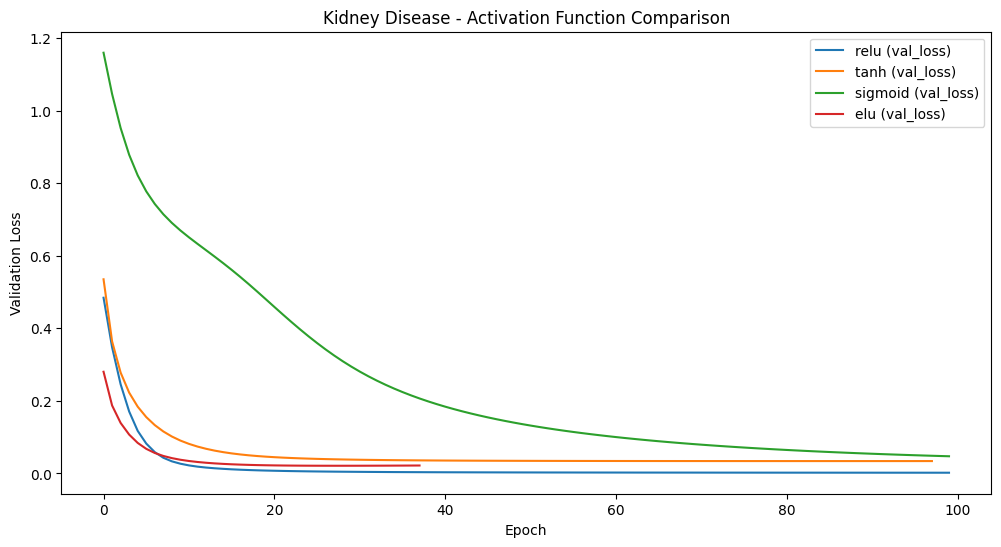

In [14]:
plt.figure(figsize=(12, 6))
for act, hist in activation_histories.items():
    plt.plot(hist.history['val_loss'], label=f'{act} (val_loss)')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Kidney Disease - Activation Function Comparison')
plt.legend()
plt.show()

## Part 4: Final Comparison Table

In [15]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1', ascending=False)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest,1.0000,1.0,1.00,1.000000,1.0
Logistic Regression,0.9875,1.0,0.98,0.989899,1.0
XGBoost,0.9875,1.0,0.98,0.989899,1.0
ANN (ReLU),0.9875,1.0,0.98,0.989899,1.0


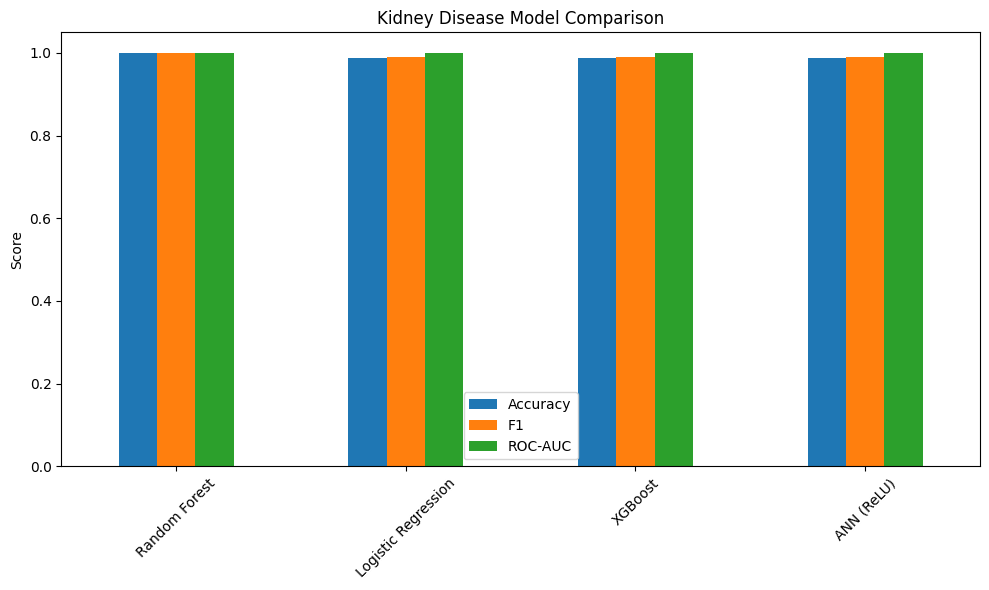

In [16]:
results_df[['Accuracy', 'F1', 'ROC-AUC']].plot(kind='bar', figsize=(10, 6))
plt.title('Kidney Disease Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Save Best Model

Note: since this dataset is small (~400 rows) and mostly categorical/clean-separable, classical ML (especially Random Forest) may actually outperform the ANN here. Check the comparison table and save whichever model scored best - swap `ann_relu.save(...)` for `joblib.dump(rf, ...)` if Random Forest wins.

In [17]:
ann_relu.save('../models/kidney_model.h5')
print('Saved: ../models/kidney_model.h5')

Saved: ../models/kidney_model.h5


## Key Takeaways (fill in after running)

- Best performing model overall: ...
- Did classical ML beat the ANN here (common on small/clean datasets like this one): ...
- Best activation function for this dataset: ...